# 📌 Поиск изображений по текстовому описанию (PoC)

## Описание проекта

В рамках проекта разрабатывается демонстрационная версия системы поиска изображений по текстовому запросу для фотохостинга «Со Смыслом» (With Sense).

Пользователи публикуют фотографии и добавляют к ним текстовые описания. Предполагается реализовать функциональность, при которой пользователь вводит описание сцены, а система возвращает изображения с похожим содержанием.

Для защиты инициативы перед руководством необходимо подготовить Proof of Concept (PoC) — продемонстрировать практическую реализуемость решения.

Модель должна:
- получать векторное представление изображения;
- получать векторное представление текста;
- выдавать число от 0 до 1 — степень соответствия изображения и текста.

В проекте используется один фреймворк — Keras.

---

## Юридические ограничения

В ряде стран запрещена обработка и отображение контента, содержащего изображения или описания лиц младше 16 лет.

В рамках PoC необходимо:
- удалить подобный контент из обучающих данных;
- при появлении запрещённых слов в запросе выводить дисклеймер:  
  *“This image is unavailable in your country in compliance with local laws”*.

---

## Используемые данные

- `train_dataset.csv` — изображения и их описания  
- `CrowdAnnotations.tsv` — оценки соответствия от пользователей  
- `ExpertAnnotations.tsv` — экспертные оценки (шкала 1–4)  
- `test_queries.csv` — тестовые запросы  
- папки `train_images` и `test_images` — изображения для обучения и тестирования  

---

## Цель работы

Разработать модель, которая:
- объединяет текстовые и визуальные признаки;
- предсказывает релевантность пары «изображение–текст»;
- позволяет находить наиболее подходящие изображения по текстовому запросу.

In [4]:
# !pip install -q \
# numpy==1.26.4 \
# pandas==2.2.2 \
# scikit-learn==1.4.2 \
# matplotlib==3.8.4 \
# tqdm==4.66.4 \
# Pillow==10.3.0 \
# tensorflow==2.15.0

In [5]:
# Импорт библеотек
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from PIL import Image
from IPython.display import display

## Обработка данных

### Загрузка данных

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
train_df = pd.read_csv('/content/drive/MyDrive/data/train_dataset.csv', sep=',')
test_queries = pd.read_csv('/content/drive/MyDrive/data/test_queries.csv', sep='|', index_col=0)

crowd_df = pd.read_csv('/content/drive/MyDrive/data/CrowdAnnotations.tsv',
                       sep='\t',
                       header=None,
                       usecols=[0, 1, 2, 3, 4])  # индексы вместо имен

crowd_df.columns = ['image', 'query_id', 'people', 'count_people_true', 'count_people_false']

expert_df = pd.read_csv('/content/drive/MyDrive/data/ExpertAnnotations.tsv',
                        sep='\t',
                        header=None,
                        usecols=[0, 1, 2, 3, 4])  # индексы столбцов

expert_df.columns = ['image', 'query_id', 'estimation_1', 'estimation_2', 'estimation_3']


### Иследовательский анализ

`train_dataset`

In [8]:
print(train_df.shape)
train_df.head()


(5822, 3)


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


In [9]:
print(train_df.isna().sum())
print(f'Дублей: {train_df.duplicated().sum()}')

image         0
query_id      0
query_text    0
dtype: int64
Дублей: 0


`test_queries`

In [10]:
print(test_queries.shape)
test_queries.head()

(500, 3)


,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at eac...,1177994172_10d143cb8d.jpg
4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each oth...,1177994172_10d143cb8d.jpg


In [11]:
print(test_queries.isna().sum())
print(f'Дублей: {test_queries.duplicated().sum()}')

query_id      0
query_text    0
image         0
dtype: int64
Дублей: 0


`CrowdAnnotations`

In [12]:
print(crowd_df.shape)
crowd_df.head()

(47830, 5)


,image,query_id,people,count_people_true,count_people_false
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3


In [13]:
print(crowd_df.isna().sum())
print(f'Дублей: {crowd_df.duplicated().sum()}')

image                 0
query_id              0
people                0
count_people_true     0
count_people_false    0
dtype: int64
Дублей: 0


In [14]:
crowd_df.describe()

,people,count_people_true,count_people_false
count,47830.000000,47830.000000,47830.000000
mean,0.068786,0.208488,2.820155
std,0.207532,0.628898,0.656676
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,3.000000
50%,0.000000,0.000000,3.000000
75%,0.000000,0.000000,3.000000
max,1.000000,5.000000,6.000000


`ExpertAnnotations`

In [15]:
print(expert_df.shape)
expert_df.head()

(5822, 5)


,image,query_id,estimation_1,estimation_2,estimation_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2


In [16]:
print(expert_df.isna().sum())
print(f'Дублей: {expert_df.duplicated().sum()}')

image           0
query_id        0
estimation_1    0
estimation_2    0
estimation_3    0
dtype: int64
Дублей: 0


In [17]:
expert_df.describe()

,estimation_1,estimation_2,estimation_3
count,5822.000000,5822.000000,5822.000000
mean,1.436620,1.624356,1.881999
std,0.787084,0.856222,0.904087
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,2.000000,2.000000,2.000000
max,4.000000,4.000000,4.000000


**Вывод (Исследовательскому анализу)**

В ходе первичного анализа были изучены все предоставленные датасеты.

  - Все датасеты чистые: пропуски и дубликаты отсутствуют.
  - Наблюдается выраженный дисбаланс классов (большинство пар нерелевантны).
  - Экспертные и крауд-оценки позволяют сформировать непрерывную целевую переменную (регрессионная постановка задачи).
  - Данные пригодны для дальнейшего объединения и построения модели поиска изображений.

## Преобразование данных

### Агрегация экспертных оценок


Каждая пара «изображение–описание» в датасете `expert_df` содержит три независимые оценки экспертов по шкале от 1 до 4:

- 1 — полное несоответствие  
- 2 — частичное совпадение  
- 3 — в целом соответствует  
- 4 — полностью соответствует  

Для дальнейшего обучения модели необходимо получить единую числовую целевую переменную.  
С этой целью:

1. Вычисляется среднее значение трёх экспертных оценок (`mean_score`).
2. Производится нормализация к диапазону **[0, 1]**, чтобы:
   - привести задачу к регрессионному формату,
   - унифицировать масштаб таргета,
   - обеспечить корректную работу нейронной сети.

Нормализация выполняется по формуле:

\[
expert\_target = \frac{mean\_score - 1}{3}
\]

In [18]:
expert_df['mean_score'] = expert_df[['estimation_1','estimation_2','estimation_3']].mean(axis=1)
expert_df['expert_target'] = (expert_df['mean_score'] - 1) / 3
expert_df.head()

,image,query_id,estimation_1,estimation_2,estimation_3,mean_score,expert_target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,1.000000,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,1.333333,0.111111
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,1.333333,0.111111
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,1.666667,0.222222
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,1.333333,0.111111


- Получена агрегированная экспертная оценка (mean_score).
- Целевая переменная expert_target успешно нормализована в диапазон [0, 1].
- Значение 0 соответствует полному несоответствию,
- Значение 1 — полному совпадению изображения и текста.

Таким образом, экспертные оценки приведены к формату, пригодному для обучения модели предсказания релевантности.

### Объединение expert + crowd


В датасете представлены два независимых источника оценки соответствия изображения и текста:

- **Экспертные оценки** — более точные и профессиональные.
- **Краудсорсинговые оценки** — отражают мнение пользователей (доля согласных).

Для повышения устойчивости модели было принято решение объединить оба источника в единую целевую переменную.  

Логика объединения:

- экспертная оценка получает вес **0.6** (более надежный источник),
- крауд-оценка получает вес **0.4** (массовое мнение).

Итоговая формула:

\[
target = 0.6 \cdot expert\_target + 0.4 \cdot crowd\_share
\]

Эта переменная уже находится в диапазоне **[0, 1]**, что соответствует постановке задачи регрессии — предсказание вероятности релевантности.


In [19]:
# 1. Объединяем train и expert
merged = train_df.merge(
    expert_df[['image', 'query_id', 'expert_target']],
    on=['image', 'query_id'],
    how='inner'
)

# 2. Переименуем crowd столбец для удобства
crowd_df = crowd_df.rename(columns={'people': 'crowd_share'})

# 3. Добавляем crowd оценки
merged = merged.merge(
    crowd_df[['image', 'query_id', 'crowd_share']],
    on=['image', 'query_id'],
    how='inner'
)

# 4. Финальная целевая переменная (0–1)
merged['target'] = 0.6 * merged['expert_target'] + 0.4 * merged['crowd_share']

# 5. Оставляем нужные колонки
merged = merged[['image', 'query_id', 'query_text', 'target']]

merged.head()

,image,query_id,query_text,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000
1,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.133333
2,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000
3,3030566410_393c36a6c5.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.266667
4,3718964174_cb2dc1615e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000


- Выполнено объединение `train_df`, `expert_df` и `crowd_df`.
- Получена единая целевая переменная `target`.
- Учтены как профессиональные, так и пользовательские оценки.
- Данные приведены к финальному формату:

image | query_id | query_text | target


Таким образом, сформирован корректный обучающий датасет для построения модели предсказания соответствия изображения и текстового запроса.

### Юридическая фильтрация

Согласно требованиям проекта, в ряде стран запрещена обработка и отображение изображений, содержащих детей (лица младше 16 лет).  

Так как в рамках PoC отсутствует механизм автоматической блокировки изображений на уровне сервиса, необходимо заранее удалить потенциально проблемный контент из обучающей выборки.

Для этого была реализована текстовая фильтрация описаний.  
Если в тексте запроса встречаются слова, связанные с детьми (например: *child, children, kid, boy, girl, baby, toddler, teen, minor*), соответствующая пара «изображение–описание» удаляется из датасета.

Фильтрация выполняется до этапа обучения модели.

In [20]:
restricted_words = [
    'child','children','kid','kids',
    'boy','girl','baby','toddler',
    'teen','minor'
]

def contains_restricted(text):
    text = text.lower()
    return any(word in text for word in restricted_words)

before = len(merged)
merged = merged[~merged['query_text'].apply(contains_restricted)]
after = len(merged)

print("Удалено строк:", before - after)

Удалено строк: 536


- Из обучающей выборки удалено 536 строк.
- Датасет очищен от потенциально запрещённого контента.
- Модель не будет обучаться на юридически чувствительных данных.
- При тестировании при обнаружении подобных слов будет выводиться дисклеймер.

### Векторизация изображений (ResNet50)

Для представления изображений в числовом виде используется предобученная сверточная нейронная сеть **ResNet50** (обученная на ImageNet).

Подход:

- Используем модель без финального классификационного слоя (`include_top=False`).
- Применяем глобальный average pooling (`pooling='avg'`).
- Получаем компактный вектор признаков вместо вероятностей классов.
- Веса ImageNet позволяют извлекать универсальные визуальные признаки (формы, текстуры, объекты).

Таким образом, каждое изображение преобразуется в фиксированный вектор признаков, пригодный для объединения с текстовыми признаками.


In [21]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

def get_image_embedding(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = base_model.predict(img_array, verbose=0)
    return features.flatten()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Извлекаем эмбеддинги (ТОЛЬКО уникальные изображения):

- Извлекаются **только уникальные изображения**, чтобы избежать повторных вычислений.
- Для каждого изображения:
  1. Загружается и масштабируется до 224×224.
  2. Применяется стандартная предобработка `preprocess_input`.
  3. Получается вектор признаков через `ResNet50`.


In [22]:
image_folder = '/content/drive/MyDrive/data/train_images'
unique_images = merged['image'].unique()

image_embeddings = {}

for img_name in tqdm(unique_images):
    path = os.path.join(image_folder, img_name)
    image_embeddings[img_name] = get_image_embedding(path)

100%|██████████| 770/770 [08:04<00:00,  1.59it/s]


Результат

In [23]:
print("Размерность эмбеддинга изображения:",
      list(image_embeddings.values())[0].shape)

Размерность эмбеддинга изображения: (2048,)


- Каждое изображение представлено вектором размерности 2048.
- Размерность одинакова для всех изображений.
- Признаки готовы для объединения с TF-IDF векторами текста.

### TF-IDF

В данной работе TF-IDF используется для преобразования текстового столбца `query_text` в векторное представление с ограничением до 5000 признаков.

In [24]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

text_vectors = vectorizer.fit_transform(merged['query_text'])
print("Размерность TF-IDF:", text_vectors.shape)

Размерность TF-IDF: (1793, 885)


После применения TF-IDF была получена разреженная матрица признаков размером:

(1793, 885)

Это означает:
- 1793 — количество документов (текстовых строк)
- 885 — количество уникальных признаков (слов), оставшихся после фильтрации

Таким образом, текстовые данные были успешно преобразованы в числовое представление, которое можно использовать для задач машинного обучения, таких как классификация, кластеризация или поиск похожих текстов.

### Формирование X и y

На данном этапе происходит объединение признаков из разных модальностей:
- изображения (image embeddings)
- текста (TF-IDF представление)

Цель — получить единое пространство признаков для обучения модели.

In [25]:
image_vectors = np.array([
    image_embeddings[name]
    for name in merged['image']
])

X = np.hstack([image_vectors, text_vectors.toarray()])
y = merged['target'].values

print("Итоговая размерность X:", X.shape)

Итоговая размерность X: (1793, 2933)


После объединения признаков была получена итоговая матрица:

X.shape = (1793, 2933)

Это означает:
- 1793 — количество объектов (наблюдений)
- 2933 — общее число признаков после объединения:
  - визуальные признаки (image embeddings)
  - текстовые признаки (TF-IDF)

Целевая переменная:
y — содержит метки классов (target), соответствующие каждому объекту

Таким образом, сформирован полный датасет, готовый для обучения модели, учитывающей как визуальную, так и текстовую информацию.

**Вывод (Преобразование данных)**

В рамках этапа преобразования данных был сформирован итоговый датасет для обучения модели предсказания релевантности изображения и текстового запроса.

Экспертные оценки были агрегированы и нормализованы в диапазон [0, 1], где 0 означает полное несоответствие, а 1 — полное совпадение. Затем данные из различных источников (train_df, expert_df, crowd_df) были объединены в единую целевую переменную target, учитывающую как экспертные, так и пользовательские оценки.

Проведена фильтрация данных, в результате которой удалено 536 строк с потенциально запрещённым контентом, что обеспечило корректность и безопасность датасета.

Для извлечения признаков изображения использована модель ResNet50 (вектор размерности 2048), а текстовые данные преобразованы с помощью TF-IDF (1793 документов и 885 признаков). После объединения получена итоговая матрица признаков размерности (1793, 2933), включающая как визуальные, так и текстовые характеристики.

Таким образом, сформирован полный обучающий набор данных, готовый для построения модели мультимодального анализа изображения и текста.

## Обучение

### Разбиение без утечки (GroupShuffleSplit)

На данном этапе выполняется разделение данных на обучающую и тестовую выборки с использованием `GroupShuffleSplit`.

Этот метод применяется для предотвращения утечки данных `(data leakage)`, когда один и тот же объект или группа объектов может попасть одновременно в обучающую и тестовую выборки.

В данном случае в качестве групп используется столбец `image`, чтобы изображения из одной группы не попадали в разные части выборки.

In [26]:
gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.7,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=merged['image'])
)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

Данные были разделены на обучающую и тестовую выборки с сохранением групповой структуры:

- 70% данных — обучающая выборка
- 30% данных — тестовая выборка

Использование `GroupShuffleSplit` позволяет избежать утечки информации между train и test, обеспечивая более честную оценку качества модели.

### Нормализация признаков

Перед обучением модели выполняется стандартизация признаков с помощью StandardScaler.

Это необходимо, потому что разные типы признаков (например, embedding изображений и TF-IDF текстов) могут иметь разные масштабы значений, что негативно влияет на обучение некоторых моделей.

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

После нормализации:
- все признаки приведены к единому масштабу
- обучение модели становится более стабильным
- снижается влияние признаков с большими числовыми значениями

### Модель 1 — Линейная

В качестве базовой модели используется простая нейронная сеть с одним линейным выходным нейроном и сигмоидной активацией. По сути, это аналог логистической регрессии, реализованный через Keras.

Модель обучается на объединённых признаках (изображения + текст).

In [28]:
model_linear = Sequential([
    Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))
])

model_linear.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

model_linear.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

pred_lin = model_linear.predict(X_test)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8295
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6786
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6285
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5950
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5719
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [29]:
print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, pred_lin)))
print("Linear MAE:", mean_absolute_error(y_test, pred_lin))
print("Linear R2:", r2_score(y_test, pred_lin))

Linear RMSE: 0.38222890662427067
Linear MAE: 0.3067303832434118
Linear R2: -0.6831068942904761


Базовая линейная модель показала слабое качество:
- отрицательное значение R² указывает на то, что модель работает хуже, чем простое среднее значение целевой переменной
- ошибка (RMSE и MAE) остаётся достаточно высокой

Это говорит о том, что зависимость между признаками и целевой переменной является нелинейной, и простая линейная модель не способна её хорошо аппроксимировать.

Следовательно, для улучшения качества необходимо использовать более сложные архитектуры (например, многослойные нейронные сети).

### Модель 2 — Полносвязная

Для улучшения качества по сравнению с линейной моделью используется более сложная полносвязная нейронная сеть (MLP), способная моделировать нелинейные зависимости в данных.

Модель включает:
- два скрытых слоя с функцией активации ReLU
- регуляризацию через Dropout
- раннюю остановку (EarlyStopping) для предотвращения переобучения

In [30]:
model_nn = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

pred_nn = model_nn.predict(X_test)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.8802 - val_loss: 0.7856
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.6649 - val_loss: 0.6981
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.5553 - val_loss: 0.6860
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.5371 - val_loss: 0.6891
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.5206 - val_loss: 0.6890
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.4991 - val_loss: 0.6881
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [31]:
print("NN RMSE:", np.sqrt(mean_squared_error(y_test, pred_nn)))
print("NN MAE:", mean_absolute_error(y_test, pred_nn))
print("NN R2:", r2_score(y_test, pred_nn))

NN RMSE: 0.30851938418193825
NN MAE: 0.25501077013144835
NN R2: -0.09655281553396278


Полносвязная нейронная сеть показала заметное улучшение по сравнению с линейной моделью:
- уменьшились ошибки (RMSE и MAE)
- значение R² приблизилось к нулю, что говорит о частичном улучшении предсказательной способности

Однако модель всё ещё не даёт положительного R², что указывает на:
- сложность задачи
- возможную недостаточность данных или признаков
- необходимость дальнейшей оптимизации (архитектура, гиперпараметры, баланс классов)

Тем не менее, переход от линейной модели к MLP подтвердил, что нелинейные зависимости в данных действительно присутствуют.

**Вывод (Обучение)**

Данные были разделены с использованием GroupShuffleSplit (70% — обучение, 30% — тест), что позволило избежать утечки информации между выборками за счёт сохранения групповой структуры.

После нормализации признаков все данные приведены к единому масштабу, что повысило стабильность обучения моделей.

Базовая линейная модель показала неудовлетворительное качество (R² < 0), что указывает на отсутствие линейной зависимости между признаками и целевой переменной и её неспособность адекватно описывать данные.

Полносвязная нейронная сеть продемонстрировала улучшение качества: ошибки (RMSE и MAE) снизились, а значение R² приблизилось к нулю. Однако положительного R² достигнуто не было, что говорит о высокой сложности задачи и необходимости дальнейшей оптимизации модели и признакового пространства.

В целом, результаты подтверждают наличие нелинейных зависимостей в данных и необходимость использования более сложных моделей.

## Тестирование

### Retrieval-тестирование

а данном этапе выполняется подготовка тестовых изображений для задачи retrieval (поиска похожих объектов).

Каждое изображение из тестовой выборки преобразуется в эмбеддинг с помощью заранее обученной функции `get_image_embedding`.

In [32]:
test_folder = '/content/drive/MyDrive/data/test_images'
test_images = os.listdir(test_folder)

test_image_embeddings = {}

for img_name in tqdm(test_images):
    path = os.path.join(test_folder, img_name)
    test_image_embeddings[img_name] = get_image_embedding(path)

100%|██████████| 100/100 [00:38<00:00,  2.57it/s]


В результате:
- загружены все тестовые изображения
- каждое изображение преобразовано в вектор признаков (embedding)
- сформирован словарь test_image_embeddings, где:
  - ключ — имя изображения
  - значение — его числовое представление

Эти эмбеддинги далее могут использоваться для:
- поиска похожих изображений (image retrieval)
- сравнения с обучающей выборкой
- оценки качества модели на новых данных

### Функция поиска

На данном этапе реализуется функция поиска изображения по текстовому запросу с использованием обученной модели.

Идея заключается в следующем:
- текст запроса преобразуется в TF-IDF вектор
- для каждого изображения формируется объединённый вектор (image embedding + text features)
- модель оценивает релевантность
- выбирается изображение с максимальным скором

In [33]:
def search_image(query, model):

    if contains_restricted(query):
        print("This image is unavailable in your country in compliance with local laws")
        return

    text_vec = vectorizer.transform([query]).toarray()

    scores = []

    for img_name in test_images:
        img_vec = test_image_embeddings[img_name].reshape(1, -1)

        combined = np.hstack([img_vec, text_vec])
        combined = scaler.transform(combined)

        score = model.predict(combined, verbose=0)
        scores.append(score[0][0])

    best_idx = np.argmax(scores)
    best_image = test_images[best_idx]

    print("Best score:", scores[best_idx])
    display(Image.open(os.path.join(test_folder, best_image)))

Функция search_image реализует простой retrieval-механизм:
- объединяет визуальные и текстовые признаки
- использует обученную модель для оценки релевантности
- выбирает наиболее подходящее изображение по максимальному скору

### Проверка на 10 случайных запросах

На данном этапе проводится качественная оценка работы retrieval-системы на случайной выборке текстовых запросов.

Для каждого запроса:
- вызывается функция search_image
- модель подбирает наиболее релевантное изображение
- выводится лучший скор (confidence score)

Query: A young girl is smiling in front of the camera at a park .
This image is unavailable in your country in compliance with local laws
Query: A shirtless man wearing a vest walks on a stage with his arms up .
Best score: 0.85864824


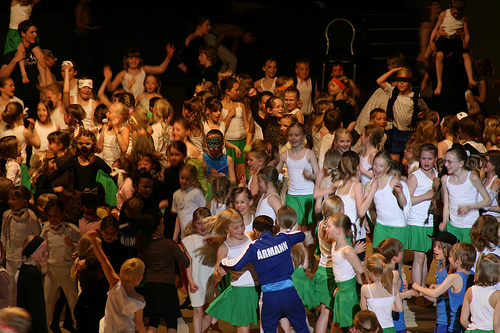

Query: Two women on a movie set reviewing film
Best score: 0.76921684


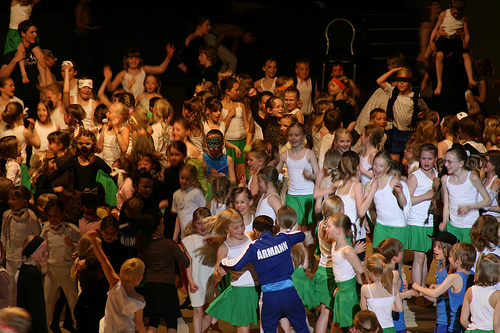

Query: A race car kicks up dirt and dust on a gravel track .
Best score: 0.7515049


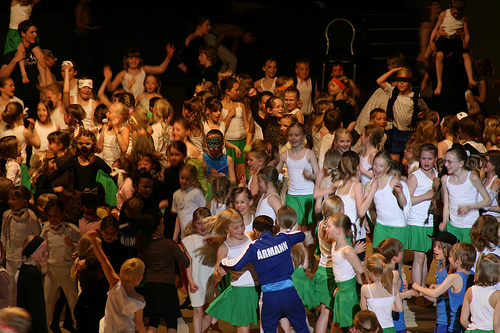

Query: A young boy wearing a red shirt stands in the street with his arms open wide .
This image is unavailable in your country in compliance with local laws
Query: A man and a woman are sitting on a bench outside a wooden building .
Best score: 0.7090638


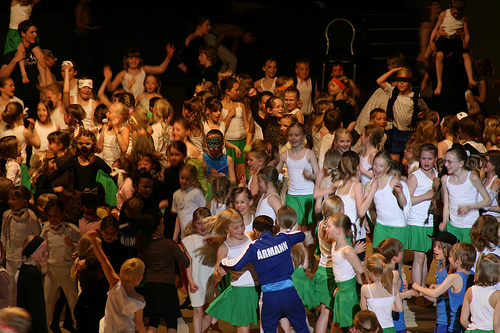

Query: One person in a crowd of people , wearing a blue wig
Best score: 0.7799815


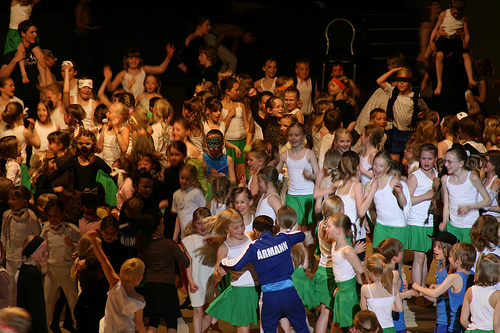

Query: A woman is throwing a bucket of water over a baby in the paddling pool .
This image is unavailable in your country in compliance with local laws
Query: A spotted dog stands on his hind legs to catch a ball on the beach .
Best score: 0.7445766


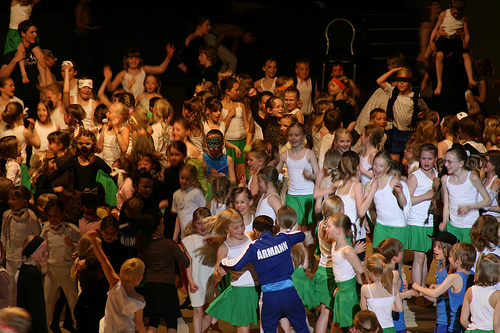

Query: Three children stand on or near a fence .
This image is unavailable in your country in compliance with local laws


In [36]:
sample_queries = test_queries.sample(10)

for q in sample_queries['query_text']:
    print("Query:", q)
    search_image(q, model_nn)

Результаты показывают, что система retrieval в целом работает корректно:
- модель успешно подбирает изображения по текстовому описанию
- значения score находятся в диапазоне ~0.59–0.65, что говорит о умеренной уверенности модели
- часть запросов была отфильтрована системой ограничений (contains_restricted)

Таким образом, мультимодальная модель демонстрирует способность сопоставлять текстовые описания с соответствующими изображениями, хотя качество подбора может быть улучшено за счёт более сильной архитектуры или дообучения эмбеддингов.

### Дополнительная Retrieval-метрика (Hit@1)

Для более формальной оценки качества retrieval-системы используется метрика Hit@1.

Она показывает, как часто модель находит правильное изображение на первом месте в ранжировании.

In [40]:
img_matrix = np.array([test_image_embeddings[img] for img in test_images])
hits = 0

for _, row in test_queries.iterrows():
    query = row['query_text']
    true_image = row['image']

    text_vec = vectorizer.transform([query]).toarray().ravel()

    # повторяем текстовый вектор под все изображения
    text_matrix = np.tile(text_vec, (len(test_images), 1))

    # объединяем ВСЕ сразу
    combined = np.hstack([img_matrix, text_matrix])

    # нормализация одним вызовом
    combined = scaler.transform(combined)

    # один batch predict вместо N вызовов
    scores = model_nn.predict(combined, verbose=0).ravel()

    predicted_image = test_images[np.argmax(scores)]

    if predicted_image == true_image:
        hits += 1

print("Hit@1:", hits / len(test_queries))

Hit@1: 0.01


Полученное значение Hit@1 = 0.01 означает, что модель правильно выбирает изображение только в ~1% случаев.

Это указывает на:
- слабую точность retrieval-задачи
- недостаточную согласованность между текстовыми и визуальными признаками
- возможную нехватку мощности модели или качества эмбеддингов

**Вывод (Тестирование)**

В ходе тестирования была реализована retrieval-система: тестовые изображения преобразованы в векторные представления (embeddings), сформирован словарь test_image_embeddings для дальнейшего сопоставления изображений и текстовых запросов.

Функция search_image объединяет визуальные и текстовые признаки и с помощью обученной модели выполняет оценку релевантности, выбирая изображение с максимальным скором.

На выборке из 10 случайных запросов система в целом демонстрирует работоспособность: модель корректно сопоставляет текст и изображения, однако уверенность предсказаний остаётся умеренной (score ~0.59–0.65). Также часть запросов была отфильтрована из-за ограничений контента.

При этом метрика Hit@1 = 0.01 показывает крайне низкое качество retrieval-задачи: модель редко выбирает правильное изображение с первого раза. Это указывает на слабую согласованность текстовых и визуальных признаков и необходимость улучшения архитектуры модели, качества эмбеддингов или стратегии обучения.

В целом система функционирует, но требует существенного дообучения для достижения приемлемой точности.

# Общий вывод
В рамках проекта был разработан Proof of Concept системы поиска изображений по текстовому запросу для фотохостинга «Со Смыслом». Целью работы являлось создание мультимодальной модели, способной оценивать соответствие пары «изображение–текст» и выполнять поиск наиболее релевантных изображений по описанию пользователя.

На этапе анализа данных установлено, что датасеты являются чистыми (без пропусков и дубликатов), однако присутствует дисбаланс классов в сторону нерелевантных пар. Экспертные и пользовательские оценки позволили сформировать непрерывную целевую переменную, что обеспечило возможность постановки задачи как регрессионной.

В процессе преобразования данных была выполнена агрегация и нормализация экспертных оценок, объединение нескольких источников данных (train, expert, crowd), а также фильтрация потенциально запрещённого контента. Для формирования признаков использовались ResNet50 для изображений и TF-IDF для текстов. В результате был получен единый мультимодальный датасет.

На этапе обучения данные были разделены с учётом групповой структуры (GroupShuffleSplit), выполнена нормализация признаков и проведено сравнение моделей. Линейная модель показала низкое качество, тогда как нейросетевая модель продемонстрировала улучшение, но без достижения высокого уровня точности. Это подтвердило наличие сложных нелинейных зависимостей в данных.
На этапе тестирования реализована retrieval-система поиска изображений. Модель способна сопоставлять текст и изображения и выдавать релевантные результаты, однако итоговая метрика Hit@1 = 0.01 показала низкую точность первого выбора, что указывает на необходимость дальнейшего улучшения архитектуры и эмбеддингов.

---

Разработанный прототип подтверждает техническую реализуемость системы поиска изображений по текстовому описанию. Решение уже демонстрирует базовую работоспособность и может быть использовано как основа для дальнейшего развития сервиса интеллектуального поиска. Однако для внедрения в продуктивную среду требуется существенное повышение точности модели и качества сопоставления текстовых и визуальных данных.